<a href="https://colab.research.google.com/github/naoufal-emsi/detection_dintrusion_PFA/blob/alae/pretraitement_cicids2017_alae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Prétraitement des données CIC-IDS2017

Cette phase traite tous les problèmes identifiés lors de l'exploration :

| # | Problème | Statut |
|---|----------|--------|
| 1 | Valeurs infinies dans `Flow Bytes/s` et `Flow Packets/s` | ✅ Traité |
| 2 | Valeurs nulles / NaN (concentrées dans WebAttacks) | ✅ Traité |
| 3 | Doublons (intra et inter-fichiers) | ✅ Traité |
| 4 | Colonnes inutiles (Unnamed, espaces) | ✅ Traité |
| 5 | Features redondantes (corrélation > 0.95) | ✅ Traité |
| 6 | Déséquilibre des classes BENIGN / ATTACK | ✅ Traité |
| 7 | Outliers + normalisation | ✅ Traité |
| 8 | Encodage de la cible + sauvegarde | ✅ Traité |

---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Importation des bibliothèques

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from collections import Counter

# Optionnel — pour SMOTE (déséquilibre des classes)
# !pip install imbalanced-learn -q
# from imblearn.over_sampling import SMOTE

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 1. Chargement et concaténation des fichiers CSV

Les 8 fichiers sont lus un par un et concaténés en un seul DataFrame.  
Le nettoyage de base (noms de colonnes, colonnes Unnamed) est appliqué dès la lecture.

In [4]:
# ============================================================
# Connexion Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/PFA_/"
csv_files = glob.glob(path + "*.csv")

print(f"Nombre de fichiers CSV trouvés : {len(csv_files)}")
for f in csv_files:
    print(" -", os.path.basename(f))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nombre de fichiers CSV trouvés : 8
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [6]:
# ============================================================
# Chargement fichier par fichier + concaténation
# ============================================================
chunks = []

for file in csv_files:
    print(f"Chargement : {os.path.basename(file)}")
    tmp = pd.read_csv(file, encoding="latin-1", low_memory=False)

    # Nettoyage immédiat des noms de colonnes
    tmp.columns = tmp.columns.str.strip()

    # Suppression des colonnes Unnamed
    tmp = tmp.loc[:, ~tmp.columns.str.contains('^Unnamed')]

    chunks.append(tmp)
    del tmp

df = pd.concat(chunks, ignore_index=True)
del chunks

print(f"\nDataset complet : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

Chargement : Monday-WorkingHours.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Chargement : Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Chargement : Tuesday-WorkingHours.pcap_ISCX.csv
Chargement : Wednesday-workingHours.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Morning.pcap_ISCX.csv
Chargement : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Dataset complet : 3,119,345 lignes x 85 colonnes


## 2. Suppression des doublons

On supprime les lignes entièrement dupliquées après la concaténation (doublons intra et inter-fichiers).

In [7]:
# ============================================================
# Suppression des doublons
# ============================================================
avant = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
apres = len(df)

print(f"Lignes avant   : {avant:,}")
print(f"Lignes après   : {apres:,}")
print(f"Doublons supprimés : {avant - apres:,} ({(avant - apres) / avant * 100:.2f}%)")

Lignes avant   : 3,119,345
Lignes après   : 2,830,541
Doublons supprimés : 288,804 (9.26%)


## 3. Traitement des valeurs infinies

Les valeurs `+inf` et `-inf` identifiées dans `Flow Bytes/s` et `Flow Packets/s`  
sont remplacées par `NaN` pour être traitées avec les valeurs nulles.

In [8]:
# ============================================================
# Remplacement des valeurs infinies par NaN
# ============================================================
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Compter avant
inf_count_before = np.isinf(df[numeric_cols]).sum().sum()
print(f"Valeurs infinies détectées : {inf_count_before:,}")

# Remplacement
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Vérification
inf_count_after = np.isinf(df[numeric_cols]).sum().sum()
print(f"Valeurs infinies après correction : {inf_count_after}")
print("Remplacement par NaN terminé.")

Valeurs infinies détectées : 4,369
Valeurs infinies après correction : 0
Remplacement par NaN terminé.


## 4. Traitement des valeurs nulles / NaN

- Les colonnes avec > 30% de NaN sont supprimées.
- Les NaN restants sont imputés avec la **médiane** de chaque colonne (robuste aux outliers).

In [9]:
# ============================================================
# Analyse des valeurs nulles
# ============================================================
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
null_df = pd.DataFrame({"nulls": null_counts, "pct": null_pct})
null_df = null_df[null_df["nulls"] > 0].sort_values("pct", ascending=False)

print(f"Colonnes avec NaN : {len(null_df)}")
display(null_df)

Colonnes avec NaN : 85


,nulls,pct
Flow Bytes/s,2864,0.101182
Flow Packets/s,2864,0.101182
Source IP,1,0.000035
Destination IP,1,0.000035
Source Port,1,0.000035
...,...,...
Idle Mean,1,0.000035
Idle Std,1,0.000035
Idle Max,1,0.000035
Idle Min,1,0.000035


In [10]:
# ============================================================
# Suppression des colonnes avec trop de NaN (> 30%)
# ============================================================
SEUIL_NAN = 0.30
cols_to_drop = null_df[null_df["pct"] > SEUIL_NAN * 100].index.tolist()

if cols_to_drop:
    print(f"Colonnes supprimées (> {SEUIL_NAN*100:.0f}% NaN) : {cols_to_drop}")
    df.drop(columns=cols_to_drop, inplace=True)
else:
    print("Aucune colonne ne dépasse le seuil de NaN.")

# ============================================================
# Imputation des NaN restants par la médiane
# ============================================================
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

# Vérification finale
remaining_nulls = df.isnull().sum().sum()
print(f"\nNaN restants après imputation : {remaining_nulls}")

Aucune colonne ne dépasse le seuil de NaN.

NaN restants après imputation : 5


## 5. Nettoyage de la colonne Label

Nettoyage des espaces dans les labels et vérification de la distribution des classes.

Distribution des classes :


,count,pct
Label,,
BENIGN,2272895,80.30
DoS Hulk,231072,8.16
PortScan,158930,5.61
DDoS,128027,4.52
DoS GoldenEye,10293,0.36
FTP-Patator,7938,0.28
SSH-Patator,5897,0.21
DoS slowloris,5796,0.20
DoS Slowhttptest,5499,0.19


/tmp/ipykernel_485/2526704482.py:18: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


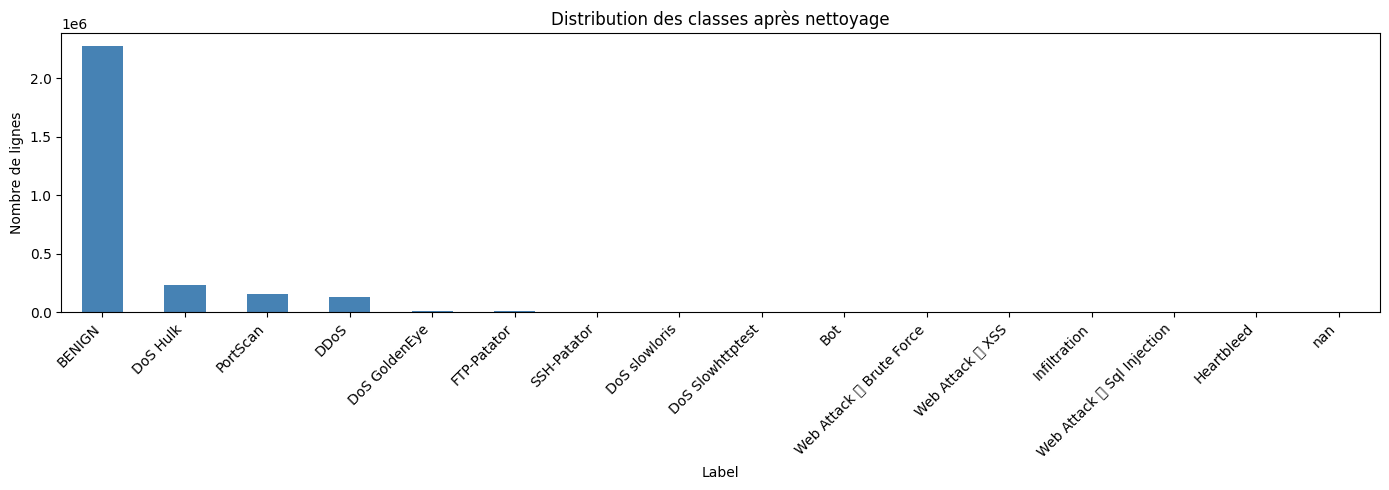

In [11]:
# ============================================================
# Nettoyage de la colonne Label
# ============================================================
df["Label"] = df["Label"].astype(str).str.strip()

# Distribution des classes
label_counts = df["Label"].value_counts()
print("Distribution des classes :")
display(label_counts.to_frame("count").assign(pct=lambda x: (x["count"] / x["count"].sum() * 100).round(2)))

# Visualisation
plt.figure(figsize=(14, 5))
label_counts.plot(kind="bar", color="steelblue")
plt.title("Distribution des classes après nettoyage")
plt.xlabel("Label")
plt.ylabel("Nombre de lignes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Suppression des features redondantes (corrélation > 0.95)

On utilise la matrice de corrélation pour identifier et supprimer les colonnes fortement corrélées  
afin de réduire la redondance et améliorer l'efficacité des modèles.

In [12]:
# ============================================================
# Suppression des features avec corrélation > 0.95
# ============================================================
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

corr_matrix = df[numeric_cols].corr().abs()

# Triangle supérieur uniquement (éviter les paires en double)
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Colonnes à supprimer
SEUIL_CORR = 0.95
cols_to_drop_corr = [col for col in upper_triangle.columns if any(upper_triangle[col] > SEUIL_CORR)]

print(f"Colonnes supprimées (corrélation > {SEUIL_CORR}) : {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)

df.drop(columns=cols_to_drop_corr, inplace=True)

print(f"\nDimensions après suppression : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

Colonnes supprimées (corrélation > 0.95) : 23
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']

Dimensions après suppression : 2,830,541 lignes x 62 colonnes


In [13]:
print(len(df.columns))

62


In [14]:
print(df.columns)

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Length of Fwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
       'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd 

In [15]:
#suppression des metadonees
cols_to_drop = ["Flow ID", "Source IP", "Source Port",
                "Destination IP", "Destination Port", "Timestamp"]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [16]:
print(df.columns)

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min',
       'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'Down/Up Ratio', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
       'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk',
       'Bwd Avg Bulk Rate', 'Init_W

## 7. Traitement des outliers + Normalisation

- **Clipping** : les valeurs au-delà du 1er et 99e percentile sont ramenées aux bornes.
- **RobustScaler** : normalisation robuste aux valeurs extrêmes, basée sur la médiane et l'IQR.

In [17]:
# ============================================================
# Séparation Features / Cible
# ============================================================
X = df.drop(columns=["Label"])
y = df["Label"].copy()

numeric_features = X.select_dtypes(include=["float64", "int64"]).columns

print(f"Features numériques : {len(numeric_features)}")
print(f"Cible : Label — {y.nunique()} classes")

Features numériques : 55
Cible : Label — 16 classes


In [18]:
# ============================================================
# Clipping des outliers (percentiles 1% — 99%)
# ============================================================
lower = X[numeric_features].quantile(0.01)
upper = X[numeric_features].quantile(0.99)

X[numeric_features] = X[numeric_features].clip(lower=lower, upper=upper, axis=1)

print("Clipping appliqué sur toutes les features numériques.")

Clipping appliqué sur toutes les features numériques.


In [19]:
# ============================================================
# Normalisation avec RobustScaler
# ============================================================
scaler = RobustScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("RobustScaler appliqué.")
print("\nAperçu des données normalisées :")
display(X[numeric_features].describe().T[["mean", "std", "min", "max"]].head(10))

RobustScaler appliqué.

Aperçu des données normalisées :


,mean,std,min,max
Protocol,0.353110,0.477937,0.000000,1.000000
Flow Duration,4.597513,10.483922,-0.009763,36.710213
Total Fwd Packets,0.942088,2.442293,-0.333333,15.333333
Total Length of Fwd Packets,2.120078,8.225969,-0.354286,65.902857
Fwd Packet Length Max,1.852524,5.548396,-0.493333,38.653333
Fwd Packet Length Min,0.394882,0.584960,-0.055556,2.083333
Fwd Packet Length Mean,0.386696,2.668236,-0.772727,22.761364
Bwd Packet Length Max,2.770038,6.651715,-0.283154,31.114695
Bwd Packet Length Min,0.519394,0.783612,0.000000,3.220779
Flow Bytes/s,3.370329,11.205378,-0.027830,74.797143


## 8. Encodage de la cible (Label)

Deux encodages sont proposés :
- **Binaire** : `BENIGN = 0`, tout le reste = `1` (détection d'intrusion simple)
- **Multi-classes** : encodage entier de chaque classe (classification fine)

In [20]:
# ============================================================
# Option A : Encodage binaire (BENIGN vs ATTACK)
# ============================================================
y_binary = y.apply(lambda x: 0 if x == "BENIGN" else 1)

print("Distribution binaire :")
counts = y_binary.value_counts()
total = len(y_binary)
for label, count in counts.items():
    nom = "BENIGN" if label == 0 else "ATTACK"
    print(f"  {nom} ({label}) : {count:,} ({count/total*100:.2f}%)")

Distribution binaire :
  BENIGN (0) : 2,272,895 (80.30%)
  ATTACK (1) : 557,646 (19.70%)


In [ ]:
# ============================================================
# Option B : Encodage multi-classes
# ============================================================
#le = LabelEncoder()
#y_multiclass = le.fit_transform(y)

#print("Mapping des classes :")
#for i, classe in enumerate(le.classes_):
#   print(f"  {i} → {classe}")

## Supression des features a variance faible

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# ============================================================
# Étape 1 — Split AVANT tout fit
# ============================================================
X = df.drop(columns=['Label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print(f"Train : {X_train.shape[0]:,} lignes")
print(f"Test  : {X_test.shape[0]:,} lignes")

# ============================================================
# Étape 2 — VarianceThreshold : fit sur train uniquement
# ============================================================
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train)

X_train_final = pd.DataFrame(
    var_selector.transform(X_train),
    columns=X_train.columns[var_selector.get_support()]
)
X_test_final = pd.DataFrame(
    var_selector.transform(X_test),
    columns=X_train.columns[var_selector.get_support()]
)

removed = X_train.columns[~var_selector.get_support()].tolist()

print(f"\nFeatures supprimées (variance < 0.01) : {len(removed)}")
print(removed)
print(f"\nFeatures finales : {X_train_final.shape[1]}")
print(X_train_final.columns.tolist())

Train : 2,264,432 lignes
Test  : 566,109 lignes

Features supprimées (variance < 0.01) : 10
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Features finales : 45
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Rat

## 9. Gestion du déséquilibre des classes (a faire en phase d'entrainement)

Trois stratégies sont proposées selon les ressources disponibles et le modèle choisi.  
> **Recommandation** : commencer par `class_weight='balanced'`, puis tester SMOTE si les résultats sont insuffisants.

In [23]:
# ============================================================
# Stratégie 1 : class_weight='balanced' (aucun rééchantillonnage)
# Compatible avec : RandomForest, LogisticRegression, SVM, etc.
# Usage : passer class_weight='balanced' à votre modèle sklearn
# Exemple :
#   from sklearn.ensemble import RandomForestClassifier
#   model = RandomForestClassifier(class_weight='balanced', random_state=42)
# ============================================================
print("Stratégie 1 : class_weight='balanced'")
print("Aucune modification de X ou y requise.")
print("Passez simplement class_weight='balanced' à votre modèle.")

Stratégie 1 : class_weight='balanced'
Aucune modification de X ou y requise.
Passez simplement class_weight='balanced' à votre modèle.


In [ ]:
# ============================================================
# Stratégie 2 : SMOTE (oversampling des classes minoritaires)
# Nécessite : pip install imbalanced-learn
# Attention : peut être lent sur un grand dataset
# ============================================================

# Décommenter si vous voulez utiliser SMOTE :

# from imblearn.over_sampling import SMOTE
# print("Distribution avant SMOTE :", Counter(y_binary))
# sm = SMOTE(random_state=42, k_neighbors=5)
# X_resampled, y_resampled = sm.fit_resample(X, y_binary)
# print("Distribution après SMOTE :", Counter(y_resampled))

print("SMOTE commenté — décommenter selon le besoin.")

In [ ]:
# ============================================================
# Stratégie 3 : Undersampling de BENIGN (rapide, sans librairie)
# Garde toutes les attaques + échantillon équilibré de BENIGN
# ============================================================

# Décommenter si vous voulez utiliser l'undersampling :

# df_combined = X.copy()
# df_combined["Label"] = y_binary.values
#
# attacks    = df_combined[df_combined["Label"] == 1]
# benign_all = df_combined[df_combined["Label"] == 0]
#
# benign_sample = benign_all.sample(n=len(attacks), random_state=42)
# df_balanced = pd.concat([attacks, benign_sample]).sample(frac=1, random_state=42)
#
# X_balanced = df_balanced.drop(columns=["Label"])
# y_balanced = df_balanced["Label"]
# print("Distribution après undersampling :", Counter(y_balanced))

print("Undersampling commenté — décommenter selon le besoin.")

## 10. Résumé du dataset prétraité

In [28]:

# ============================================================
# Résumé final
# ============================================================
print("=" * 50)
print(" RÉSUMÉ DU DATASET PRÉTRAITÉ")
print("=" * 50)

print("\n DONNÉES D'ENTRAÎNEMENT")
print(f"  Lignes          : {X_train_final.shape[0]:,}")
print(f"  Features        : {X_train_final.shape[1]}")
print(f"  NaN restants    : {X_train_final.isnull().sum().sum()}")
print(f"  Inf restants    : {np.isinf(X_train_final.select_dtypes(include=['float64','int64'])).sum().sum()}")
print(f"  BENIGN          : {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.2f}%)")
print(f"  ATTACK          : {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.2f}%)")

print("\n DONNÉES DE TEST")
print(f"  Lignes          : {X_test_final.shape[0]:,}")
print(f"  Features        : {X_test_final.shape[1]}")
print(f"  NaN restants    : {X_test_final.isnull().sum().sum()}")
print(f"  Inf restants    : {np.isinf(X_test_final.select_dtypes(include=['float64','int64'])).sum().sum()}")
print(f"  BENIGN          : {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.2f}%)")
print(f"  ATTACK          : {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.2f}%)")

print("\n" + "=" * 50)
print("Variables disponibles pour la modélisation :")
print("  X_train_final → features train, nettoyées et normalisées")
print("  X_test_final  → features test,  nettoyées et normalisées")
print("  y_train       → cible binaire train (0=BENIGN, 1=ATTACK)")
print("  y_test        → cible binaire test  (0=BENIGN, 1=ATTACK)")
print("  scaler        → RobustScaler fitté sur train")
print("  var_selector  → VarianceThreshold fitté sur train")
print("=" * 50)


 RÉSUMÉ DU DATASET PRÉTRAITÉ

 DONNÉES D'ENTRAÎNEMENT
  Lignes          : 2,264,432
  Features        : 45
  NaN restants    : 0
  Inf restants    : 0
  BENIGN          : 1,818,315 (80.30%)
  ATTACK          : 446,117 (19.70%)

 DONNÉES DE TEST
  Lignes          : 566,109
  Features        : 45
  NaN restants    : 0
  Inf restants    : 0
  BENIGN          : 454,580 (80.30%)
  ATTACK          : 111,529 (19.70%)

Variables disponibles pour la modélisation :
  X_train_final → features train, nettoyées et normalisées
  X_test_final  → features test,  nettoyées et normalisées
  y_train       → cible binaire train (0=BENIGN, 1=ATTACK)
  y_test        → cible binaire test  (0=BENIGN, 1=ATTACK)
  scaler        → RobustScaler fitté sur train
  var_selector  → VarianceThreshold fitté sur train


## 11. Sauvegarde du dataset prétraité

In [29]:
# ============================================================
# Sauvegarde dans Google Drive
# ============================================================
output_path = "/content/drive/MyDrive/PFA_/preprocessed/"
os.makedirs(output_path, exist_ok=True)

# Sauvegarde train
X_train_final.to_csv(output_path + "X_train.csv", index=False)
print("X_train sauvegardé.")

y_train.to_csv(output_path + "y_train.csv", index=False, header=True)
print("y_train sauvegardé.")

# Sauvegarde test
X_test_final.to_csv(output_path + "X_test.csv", index=False)
print("X_test sauvegardé.")

y_test.to_csv(output_path + "y_test.csv", index=False, header=True)
print("y_test sauvegardé.")

print(f"\nTous les fichiers sauvegardés dans : {output_path}")

X_train sauvegardé.
y_train sauvegardé.
X_test sauvegardé.
y_test sauvegardé.

Tous les fichiers sauvegardés dans : /content/drive/MyDrive/PFA_/preprocessed/


## 12. Visualisations finales de contrôle

/tmp/ipykernel_485/1139343764.py:20: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_485/1139343764.py:21: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(output_path + "distribution_classes.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


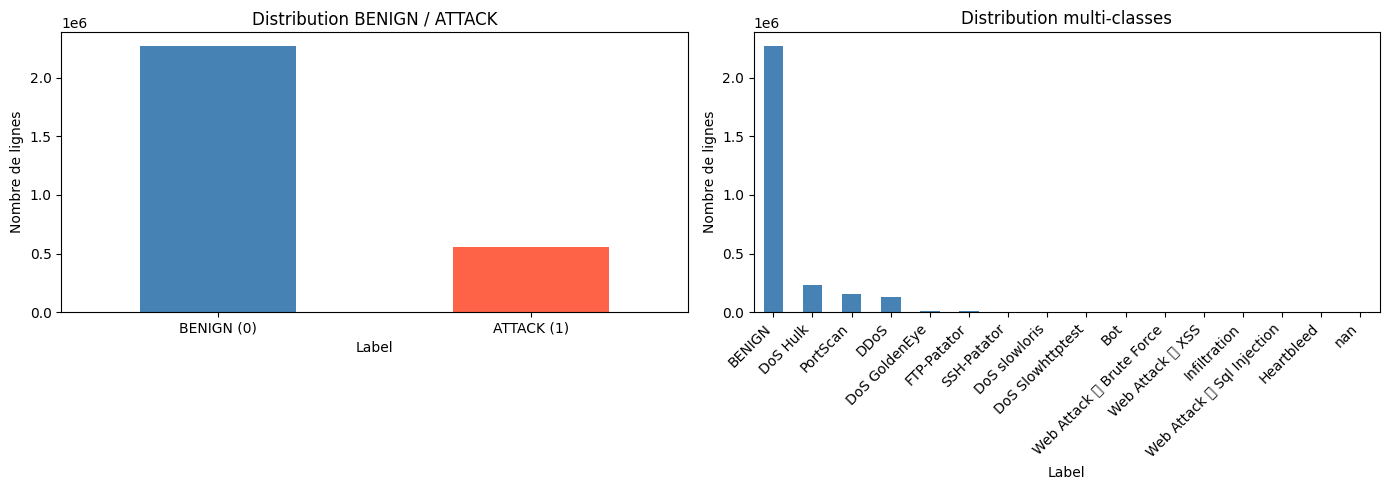

Graphique sauvegardé.


In [30]:
# ============================================================
# Distribution finale binaire
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution binaire
y_binary.value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"]
)
axes[0].set_title("Distribution BENIGN / ATTACK")
axes[0].set_xticklabels(["BENIGN (0)", "ATTACK (1)"], rotation=0)
axes[0].set_ylabel("Nombre de lignes")

# Distribution multi-classes
y.value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Distribution multi-classes")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_ylabel("Nombre de lignes")

plt.tight_layout()
plt.savefig(output_path + "distribution_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé.")

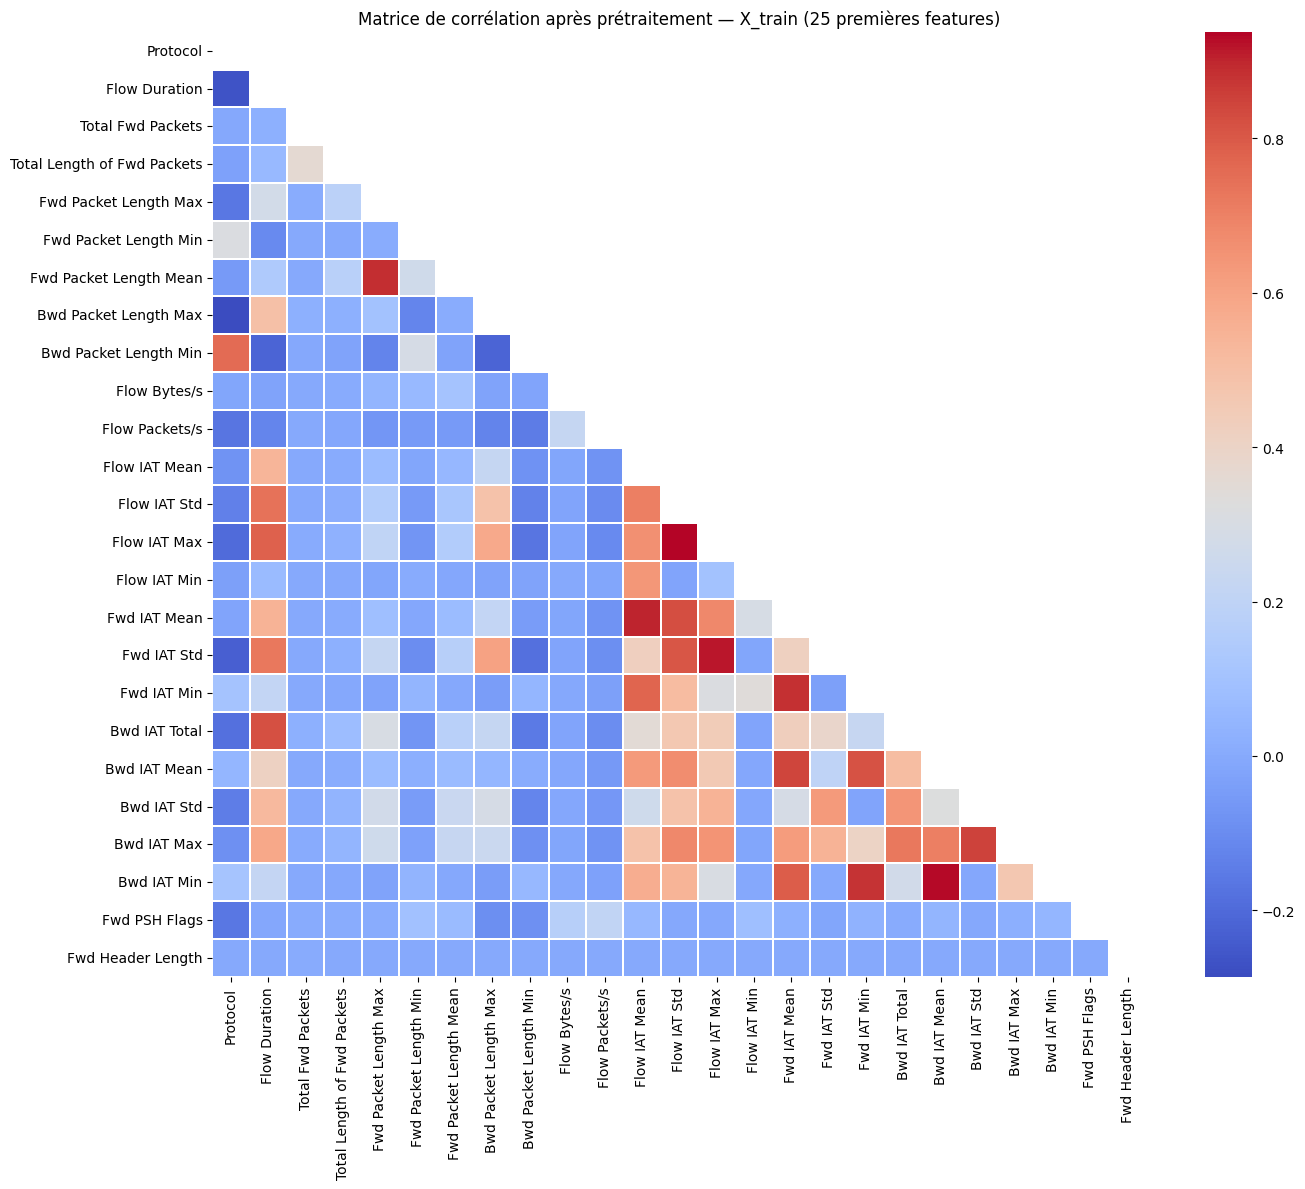

Matrice de corrélation sauvegardée.


In [31]:
# ============================================================
# Heatmap de corrélation après nettoyage
# ============================================================
sample_cols = X_train_final.select_dtypes(include=["float64", "int64"]).columns[:25]
corr_clean = X_train_final[sample_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(
    corr_clean, mask=mask, cmap="coolwarm",
    linewidths=0.3, xticklabels=True, yticklabels=True
)
plt.title("Matrice de corrélation après prétraitement — X_train (25 premières features)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(output_path + "correlation_matrix_clean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Matrice de corrélation sauvegardée.")